In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import torch
from torch import nn
from tqdm import tqdm
from linformer import Linformer
from vit_pytorch.efficient import ViT
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

In [2]:
import os
os.environ['TORCH_USE_CUDA_DSA']="1"
os.environ['CUDA_LAUNCH_BLOCKING']="1"

Load the data

In [3]:
connectome_data = pd.read_csv("./dataset/widsdatathon2025/TRAIN_CORRECTED/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")

qu_df = pd.read_excel("dataset/widsdatathon2025/TRAIN_CORRECTED/TRAIN_QUANTITATIVE_METADATA_new.xlsx")
# qu_df = qu_df.drop(index=qu_df.query('MRI_Track_Age_at_Scan >= 10 & MRI_Track_Age_at_Scan <= 10').index)
# qu_df = qu_df.drop(index=qu_df[qu_df["MRI_Track_Age_at_Scan"].isna() == True].index)

# connectome_data = connectome_data.drop(index=connectome_data[connectome_data["participant_id"].isin(qu_df["participant_id"].values) == False].index)


In [4]:
train_labels = pd.read_excel("./dataset/widsdatathon2025/TRAIN_CORRECTED/TRAINING_SOLUTIONS.xlsx")

# train_labels = train_labels.drop(index=connectome_data[connectome_data["participant_id"].isin(qu_df["participant_id"].values) == False].index)


In [5]:
# split the data into 4 splits
train_labels_adhd_male = train_labels[(train_labels["ADHD_Outcome"] == 1) & (train_labels["Sex_F"] == 0)]
train_labels_adhd_female = train_labels[(train_labels["ADHD_Outcome"] == 1) & (train_labels["Sex_F"] == 1)]
train_labels_no_adhd_male = train_labels[(train_labels["ADHD_Outcome"] == 0) & (train_labels["Sex_F"] == 0)]
train_labels_no_adhd_female = train_labels[(train_labels["ADHD_Outcome"] == 0) & (train_labels["Sex_F"] == 1)]

In [6]:
connectome_data_adhd_male = connectome_data[connectome_data['participant_id'].isin(train_labels_adhd_male['participant_id'])]
connectome_data_adhd_female = connectome_data[connectome_data['participant_id'].isin(train_labels_adhd_female['participant_id'])]
connectome_data_no_adhd_male = connectome_data[connectome_data['participant_id'].isin(train_labels_no_adhd_male['participant_id'])]
connectome_data_no_adhd_female = connectome_data[connectome_data['participant_id'].isin(train_labels_no_adhd_female['participant_id'])]

In [7]:
expected_num_regions = 200

# Build Adjacency matrices for 4 classes - ADHD (male), ADHD (female), No ADHD (male), No ADHD (female)

In [8]:
def construct_adjacency_matrix(connectome_data):
    connectivity_vectors = connectome_data.iloc[:, 1:].values
    num_patients = connectome_data.shape[0]

    upper_tri_indices = np.triu_indices(expected_num_regions, k=1)

    matrix_full = np.zeros((num_patients, expected_num_regions, expected_num_regions))

    for i in range(num_patients):
        matrix = np.zeros((expected_num_regions, expected_num_regions))
        matrix[upper_tri_indices] = connectivity_vectors[i]
        matrix += matrix.T
        np.fill_diagonal(matrix, 0)
        matrix_full[i] = matrix

    return matrix_full

In [9]:
print(connectome_data_adhd_male.shape)
print(connectome_data_adhd_male.iloc[0,0])
type(connectome_data_adhd_male)
cdam_t = connectome_data_adhd_male.drop(columns=["participant_id"]).transpose()

(392, 19901)
70z8Q2xdTXM3


In [10]:
# def make_ctme_image(row:pd.Series, imageDir = "CTME_images/"):
#   data =np.array([row[1:].to_numpy(dtype=np.float32)])
#   data = np.append(data, np.zeros(shape=(1,100), dtype=np.float32))
#   data = data.reshape((200,100))
#   # data = np.abs(data)
#   data = (data + 1.0)/2.
#   return data

def make_ctme_image(row:pd.Series, imageDir = "CTME_images/"):
  data = np.array([row[1:].to_numpy(dtype=np.float32)])
  data = (data+1.0)/2.0
  data = data*(data>=0.05).astype(np.float32)
  data = (data - data.min())/(data.max() - data.min())
  data = np.append(data, np.zeros(shape=(1,100), dtype=np.float32))
  data = data.reshape((200,100))

  return data


In [11]:
matrix_adhd_male = np.array([make_ctme_image(row) for index, row in connectome_data_adhd_male.iterrows()])

In [12]:
matrix_adhd_female = np.array([make_ctme_image(row) for index, row in connectome_data_adhd_female.iterrows()])

In [13]:
matrix_no_adhd_female = np.array([make_ctme_image(row) for index, row in connectome_data_no_adhd_female.iterrows()])

In [14]:
matrix_no_adhd_male = np.array([make_ctme_image(row) for index, row in connectome_data_no_adhd_male.iterrows()])

In [15]:
print(len(matrix_no_adhd_female)+len(matrix_adhd_female))
print(len(matrix_no_adhd_male)+len(matrix_adhd_male))

274
538


In [16]:
import matplotlib.pyplot as plt
def make_ctme_image(row:pd.Series, ind, imageDir = "CTME_images/"):

  data=row[1:]

  # data = np.array([row[1:].to_numpy(dtype=np.float32)])
  data = (data+1.0)/2.0
  # data = data*(data>=0.95).astype(np.float32)
  data = (data<=0.5).astype(np.float32)
  # data = (data - data.min())/(data.max() - data.min())
  data = 1.0 - data

  data = np.append(data, np.zeros(shape=(1,100), dtype=np.float32))

  data = data.reshape((200,100))


  plt.imsave(os.path.join(imageDir, f'{ind}.jpg'), data, cmap="Greys")


In [17]:


# i = 0
# for row in matrix_adhd_male:
#   make_ctme_image(row, i, "./CTME_images/ctme_adhd")
#   i+=1
# for row in matrix_adhd_female:
#   make_ctme_image(row, i, "./CTME_images/ctme_adhd")
#   i+=1

# i = 0
# for row in matrix_no_adhd_male:
#   make_ctme_image(row, i, "./CTME_images/ctme_no_adhd")
#   i+=1
# for row in matrix_no_adhd_female:
#   make_ctme_image(row, i, "./CTME_images/ctme_no_adhd")
#   i+=1

# i = 0
# for row in matrix_adhd_male:
#   make_ctme_image(row, i, "./CTME_images/male")
#   i+=1
# for row in matrix_no_adhd_male:
#   make_ctme_image(row, i, "./CTME_images/male")
#   i+=1

# i = 0
# for row in matrix_adhd_female:
#   make_ctme_image(row, i, "./CTME_images/female")
#   i+=1
# for row in matrix_no_adhd_female:
#   make_ctme_image(row, i, "./CTME_images/female")
#   i+=1


# os.system("ffmpeg -i ./CTME_images/female/%d.jpg ./female.gif -y")
# os.system("ffmpeg -i ./CTME_images/male/%d.jpg ./male.gif -y")
# os.system("ffmpeg -i ./CTME_images/ctme_adhd/%d.jpg ./adhd.gif -y")
# os.system("ffmpeg -i ./CTME_images/ctme_no_adhd/%d.jpg ./no_adhd.gif -y")

In [18]:
# matrix_adhd_male = construct_adjacency_matrix(connectome_data_adhd_male)
# print(type(matrix_adhd_male))
# matrix_adhd_female = construct_adjacency_matrix(connectome_data_adhd_female)
# matrix_no_adhd_male = construct_adjacency_matrix(connectome_data_no_adhd_male)
# matrix_no_adhd_female = construct_adjacency_matrix(connectome_data_no_adhd_female)

In [19]:
print(matrix_adhd_male.shape)
print(matrix_adhd_female.shape)
print(matrix_no_adhd_male.shape)
print(matrix_no_adhd_female.shape)

(392, 200, 100)
(164, 200, 100)
(146, 200, 100)
(110, 200, 100)


In [20]:
# sns.heatmap(matrix_adhd_female[0])

In [21]:
# combined_matrix_dataset = list(matrix_adhd_female) + list(matrix_adhd_male) + list(matrix_no_adhd_male) + list(matrix_no_adhd_female)

combined_matrix_dataset = list(matrix_adhd_female) + list(matrix_no_adhd_female) + list(matrix_adhd_male) + list(matrix_no_adhd_male)

combined_matrix_dataset = np.array(combined_matrix_dataset)

In [22]:
labels = np.array([1] * (392+164) + [0] * (146+110)).astype(np.float32)
# labels = np.array(labels).astype(np.float32)


In [23]:
print(combined_matrix_dataset.shape)
print(len(labels))

print(labels)

(812, 200, 100)
812
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 

Dataset Class

In [24]:
class ConnectomeMapDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        self.filelength = len(self.files)
        return self.filelength

    def __getitem__(self, idx):
        file = self.files[idx]
        file = file.reshape((1, file.shape[0], file.shape[1]))
        label = self.labels[idx]

        return file, label


In [25]:
train_list, test_list, train_labels, test_labels = train_test_split(combined_matrix_dataset, labels, test_size=0.2, random_state=42, shuffle=True)


In [26]:
train_data = ConnectomeMapDataset(train_list, train_labels)
test_data = ConnectomeMapDataset(test_list, test_labels)

In [27]:
# Training settings
batch_size = 64
epochs = 100
lr = 3e-5
gamma = 0.7
seed = 42

In [28]:
train_loader = DataLoader(dataset = train_data, batch_size=batch_size, shuffle=True )
test_loader = DataLoader(dataset = test_data, batch_size=batch_size, shuffle=True)

In [29]:
print(len(train_data), len(train_loader))


649 11


In [30]:
print(len(test_data), len(test_loader))

163 3


# Model

In [31]:
import matplotlib.pyplot as plt

def makeAccGraph(stats):
  fig, ax = plt.subplots(1, 2, figsize=(8,4))
  ax[0].plot(stats["Accuracy"], label="Accuracy")
  ax[0].plot(stats["Val Accuracy"], label="Validation accuracy")
  ax[1].plot(stats["Loss"], label="Loss")
  ax[1].plot(stats["Val Loss"], label="Validation loss")
  ax[0].legend()
  ax[1].legend()
  ax[0].set_xlabel("Epoch")
  ax[1].set_xlabel("Epoch")
  plt.legend()
  plt.savefig("training-graph.png")


In [32]:
device = 'cuda'

In [33]:
efficient_transformer = Linformer(
    dim=128,
    seq_len=400+1,  # 7x7 patches + 1 cls-token
    depth=12,
    heads=8,
    k=64
)

In [34]:
model = ViT(
    dim=128,
    image_size=200,
    patch_size=10,
    num_classes=1,
    transformer=efficient_transformer,
    channels=1,
).to(device)

In [35]:
# loss function
criterion = nn.BCELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
# scheduler
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

100%|██████████| 11/11 [00:01<00:00,  9.69it/s]


tensor([0.7816, 0.7748, 0.7859, 0.7824, 0.7807, 0.7780, 0.7814, 0.7795, 0.7842,
        0.7739, 0.7726, 0.7764, 0.7765, 0.7805, 0.7844, 0.7829, 0.7840, 0.7823,
        0.7746, 0.7777, 0.7693, 0.7809, 0.7786, 0.7914, 0.7869, 0.7963, 0.7857,
        0.7795, 0.7805, 0.7922, 0.7891, 0.7736, 0.7770, 0.7837, 0.7905, 0.7935,
        0.7779, 0.7884, 0.7863, 0.7765, 0.7894, 0.7760, 0.7792, 0.7789, 0.7823,
        0.7844, 0.7767, 0.7759, 0.7860, 0.7842, 0.7783, 0.7822, 0.7865, 0.7855,
        0.7778, 0.7813, 0.7792, 0.7856, 0.7727, 0.7768, 0.7647, 0.7824, 0.7811,
        0.7833], device='cuda:0')
tensor([0.7856, 0.7798, 0.7727, 0.7800, 0.7795, 0.7833, 0.7876, 0.7799, 0.7894,
        0.7842, 0.7740, 0.7772, 0.7805, 0.7715, 0.7865, 0.7792, 0.7889, 0.7771,
        0.7813, 0.7816, 0.7841, 0.7726, 0.7856, 0.7796, 0.7792, 0.7742, 0.7803,
        0.7679, 0.7825, 0.7826, 0.7761, 0.7811, 0.7742, 0.7775, 0.7911, 0.7794,
        0.7822, 0.7884, 0.7788, 0.7848, 0.7851, 0.7880, 0.7841, 0.7932, 0.7808,
      

100%|██████████| 11/11 [00:00<00:00, 13.17it/s]


tensor([0.7635, 0.7687, 0.7726, 0.7583, 0.7588, 0.7558, 0.7633, 0.7581, 0.7651,
        0.7582, 0.7536, 0.7628, 0.7590, 0.7439, 0.7532, 0.7608, 0.7529, 0.7648,
        0.7626, 0.7536, 0.7489, 0.7589, 0.7594, 0.7568, 0.7591, 0.7638, 0.7621,
        0.7640, 0.7563, 0.7564, 0.7676, 0.7572, 0.7620, 0.7665, 0.7638, 0.7611,
        0.7562, 0.7666, 0.7579, 0.7561, 0.7546, 0.7557, 0.7646, 0.7525, 0.7640,
        0.7537, 0.7601, 0.7612, 0.7643, 0.7641, 0.7630, 0.7609, 0.7605, 0.7619,
        0.7488, 0.7583, 0.7538, 0.7629, 0.7636, 0.7590, 0.7604, 0.7636, 0.7594,
        0.7707], device='cuda:0')
tensor([0.7588, 0.7538, 0.7704, 0.7494, 0.7600, 0.7661, 0.7696, 0.7564, 0.7666,
        0.7496, 0.7625, 0.7615, 0.7622, 0.7649, 0.7638, 0.7751, 0.7580, 0.7574,
        0.7651, 0.7625, 0.7553, 0.7582, 0.7524, 0.7523, 0.7489, 0.7602, 0.7571,
        0.7610, 0.7596, 0.7622, 0.7557, 0.7559, 0.7564, 0.7537, 0.7575, 0.7485,
        0.7605, 0.7628, 0.7596, 0.7518, 0.7650, 0.7583, 0.7478, 0.7528, 0.7560,
      

100%|██████████| 11/11 [00:00<00:00, 13.13it/s]


...

tensor([0.9908, 0.0190, 0.9983, 0.9983, 0.9968, 0.0023, 0.9982, 0.9970, 0.9912,
        0.9976, 0.4364, 0.9982, 0.9986, 0.9985, 0.9593, 0.9981, 0.9977, 0.0045,
        0.9938, 0.9983, 0.9983, 0.9981, 0.9956, 0.0039, 0.9561, 0.9930, 0.9985,
        0.0020, 0.9984, 0.9982, 0.9983, 0.9905, 0.9983, 0.9981, 0.9981, 0.9984,
        0.9982, 0.9984, 0.9977, 0.9981, 0.9958, 0.9985, 0.9972, 0.9979, 0.9984,
        0.9982, 0.6404, 0.9317, 0.7145, 0.9939, 0.9983, 0.9903, 0.9984, 0.0029,
        0.9985, 0.0036, 0.0991, 0.9980, 0.9980, 0.0265, 0.0123, 0.0021, 0.0045,
        0.9969], device='cuda:0')
tensor([0.0175, 0.0155, 0.4664, 0.9984, 0.1226, 0.0909, 0.9985, 0.0374, 0.9983,
        0.9979, 0.9976, 0.9984, 0.9980, 0.9937, 0.0021, 0.9975, 0.0028, 0.7812,
        0.9980, 0.9984, 0.9684, 0.9984, 0.9980, 0.9973, 0.9980, 0.0022, 0.8592,
        0.9982, 0.0251, 0.0083, 0.0025, 0.9895, 0.0150, 0.9985, 0.9984, 0.9983,
        0.9286, 0.9971, 0.0107, 0.9985, 0.9985, 0.9984, 0.9984, 0.9516, 0.9985,
      

100%|██████████| 11/11 [00:00<00:00, 13.20it/s]


tensor([0.9981, 0.0021, 0.9958, 0.9974, 0.0732, 0.0043, 0.0096, 0.9956, 0.9949,
        0.9984, 0.5771, 0.1935, 0.9877, 0.0020, 0.2798, 0.9984, 0.9982, 0.9924,
        0.9981, 0.9982, 0.9982, 0.9984, 0.9981, 0.9984, 0.0435, 0.0155, 0.9982,
        0.9985, 0.9983, 0.9970, 0.9977, 0.9979, 0.0028, 0.9979, 0.9983, 0.9984,
        0.9983, 0.9954, 0.9980, 0.9980, 0.9145, 0.9985, 0.9980, 0.9975, 0.9981,
        0.9985, 0.9936, 0.9984, 0.9954, 0.9983, 0.9983, 0.0248, 0.9985, 0.9972,
        0.9606, 0.9984, 0.0042, 0.9982, 0.9982, 0.0034, 0.9958, 0.0023, 0.0948,
        0.0025], device='cuda:0')
tensor([0.9938, 0.9980, 0.0210, 0.0024, 0.9986, 0.6694, 0.9934, 0.9891, 0.9975,
        0.7259, 0.9984, 0.9968, 0.0131, 0.9976, 0.9976, 0.9983, 0.9985, 0.9369,
        0.9985, 0.9981, 0.0682, 0.0146, 0.0130, 0.9486, 0.9984, 0.9981, 0.9978,
        0.9983, 0.9899, 0.9984, 0.0036, 0.9980, 0.0502, 0.9950, 0.9983, 0.0020,
        0.0079, 0.9959, 0.0027, 0.9984, 0.9981, 0.9103, 0.9982, 0.9986, 0.9979,
      

100%|██████████| 11/11 [00:00<00:00, 13.30it/s]


tensor([0.8565, 0.9956, 0.9985, 0.0914, 0.2433, 0.9560, 0.9982, 0.9906, 0.9984,
        0.9983, 0.9972, 0.0356, 0.0150, 0.9960, 0.9981, 0.0164, 0.9981, 0.0020,
        0.9281, 0.9985, 0.9957, 0.9982, 0.9983, 0.9984, 0.0022, 0.9961, 0.9986,
        0.1964, 0.0025, 0.0103, 0.9984, 0.9984, 0.9981, 0.9985, 0.6418, 0.9981,
        0.9974, 0.9985, 0.9958, 0.9977, 0.9984, 0.0033, 0.9980, 0.0020, 0.9980,
        0.9982, 0.9519, 0.9984, 0.6301, 0.9981, 0.9943, 0.0034, 0.9971, 0.9940,
        0.0143, 0.3330, 0.9981, 0.9983, 0.9977, 0.9984, 0.9682, 0.9976, 0.9982,
        0.9908], device='cuda:0')
tensor([0.9514, 0.0871, 0.0175, 0.1167, 0.9985, 0.9981, 0.9986, 0.0061, 0.9980,
        0.9983, 0.9969, 0.9983, 0.9985, 0.9983, 0.9985, 0.9985, 0.9982, 0.9935,
        0.9976, 0.7105, 0.9981, 0.0084, 0.9985, 0.9985, 0.0237, 0.4526, 0.9980,
        0.9983, 0.0253, 0.9979, 0.9337, 0.9985, 0.9982, 0.9894, 0.9980, 0.9985,
        0.9331, 0.9981, 0.9984, 0.0024, 0.9982, 0.9983, 0.0021, 0.9604, 0.9975,
      

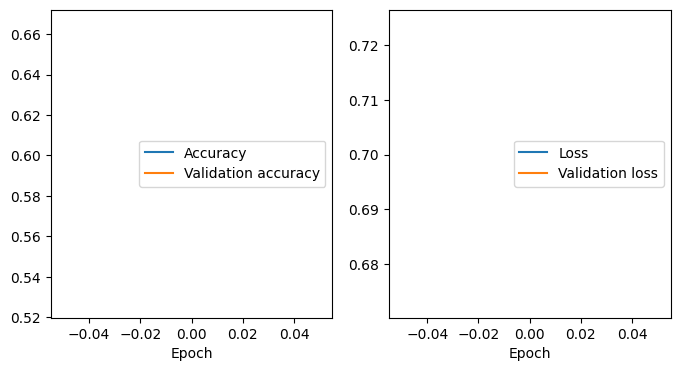

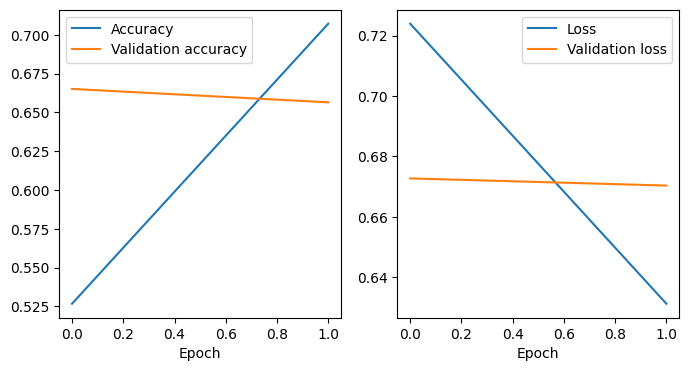

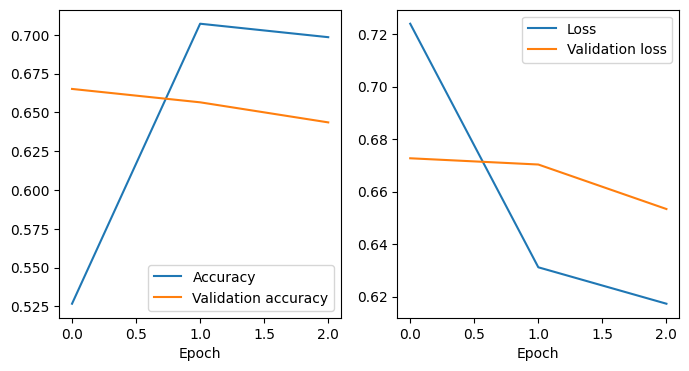

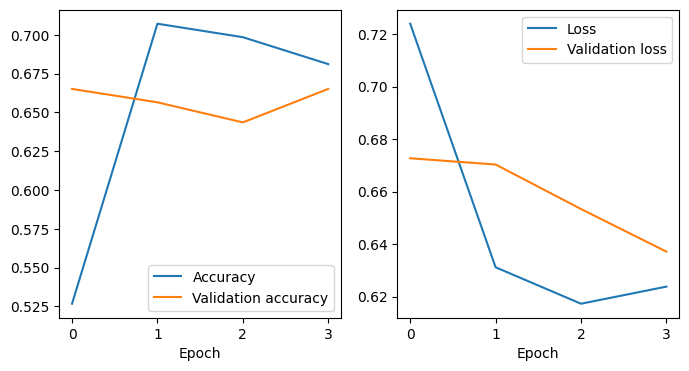

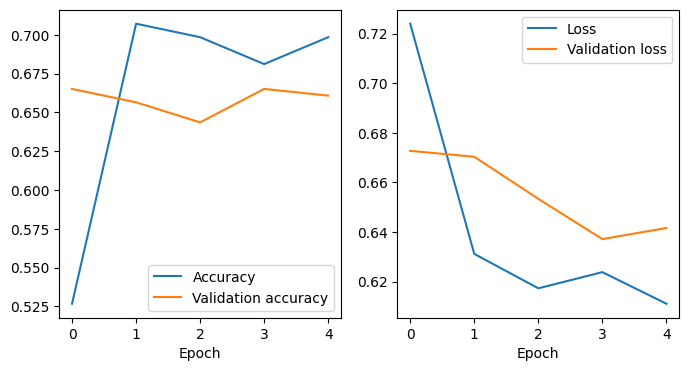

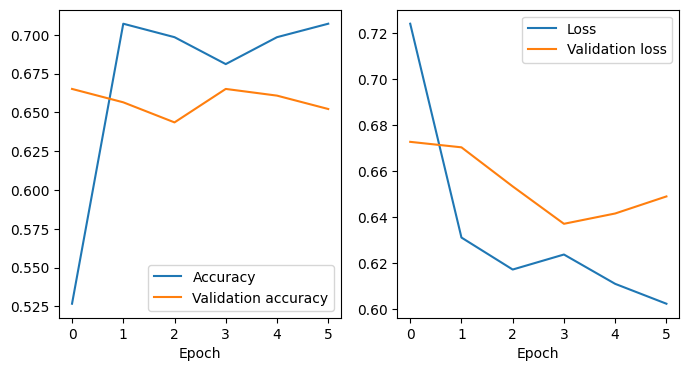

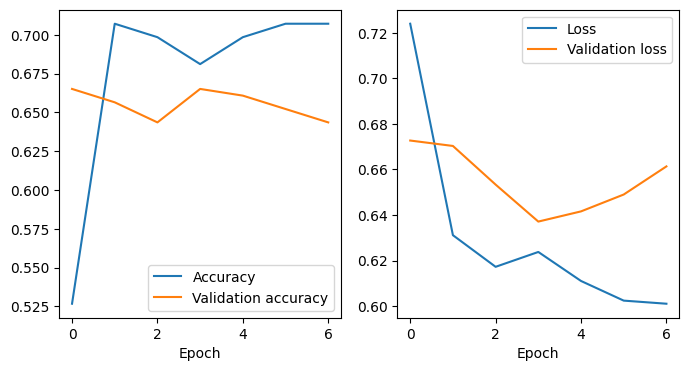

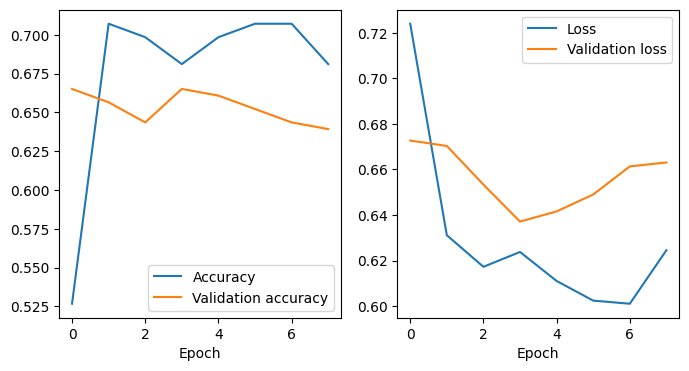

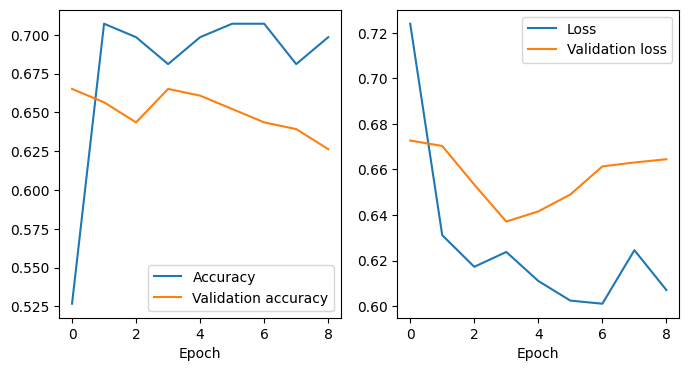

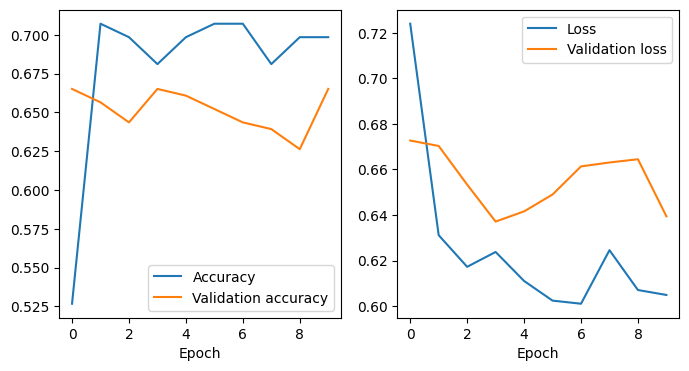

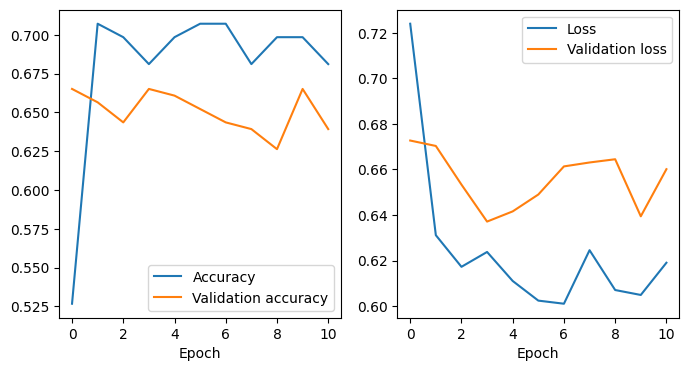

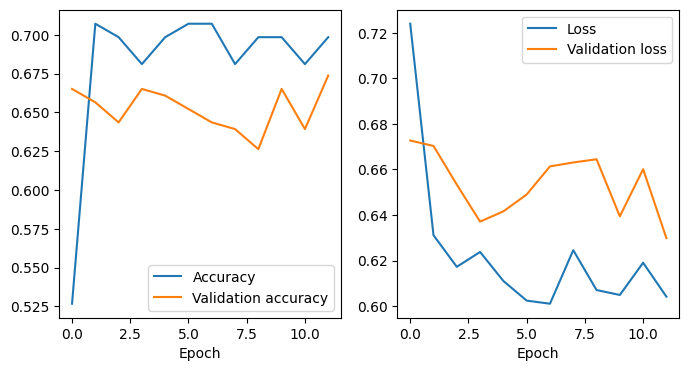

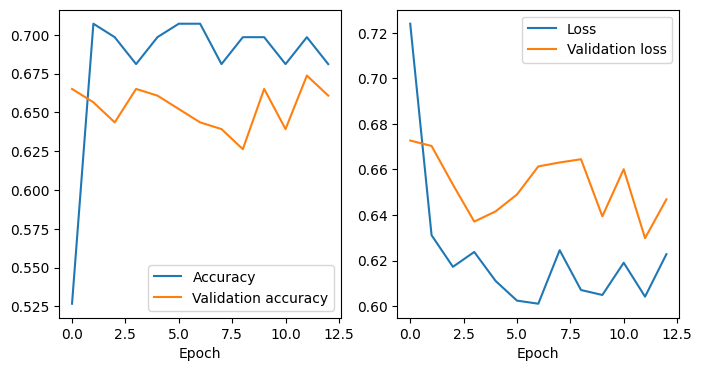

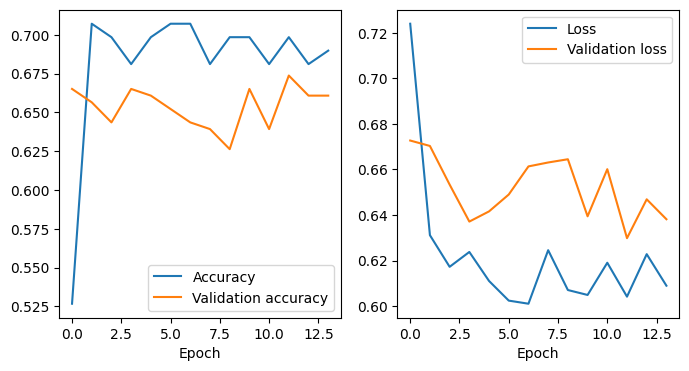

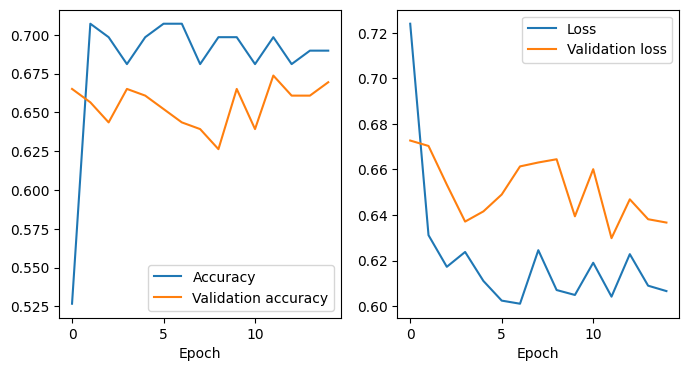

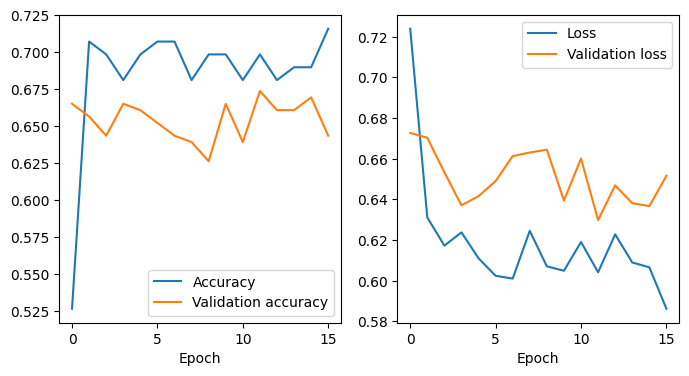

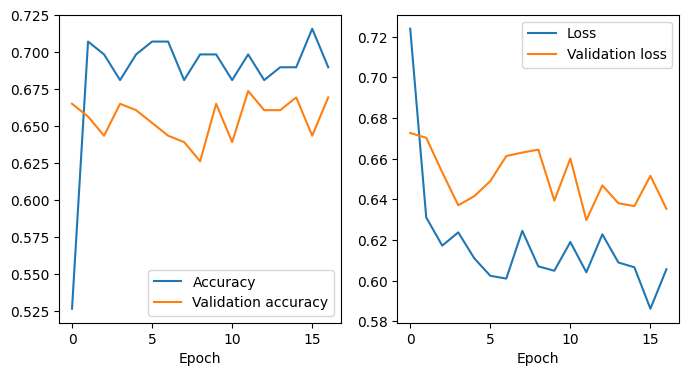

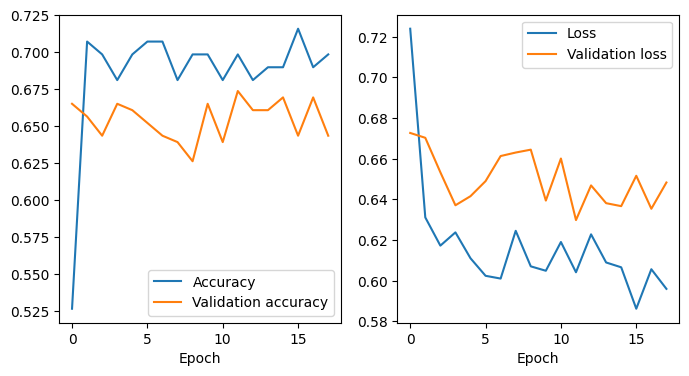

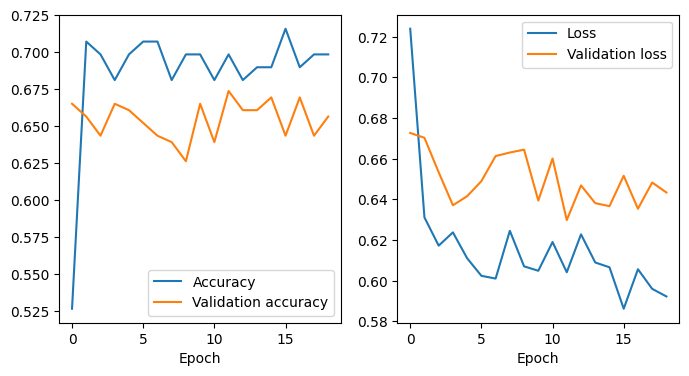

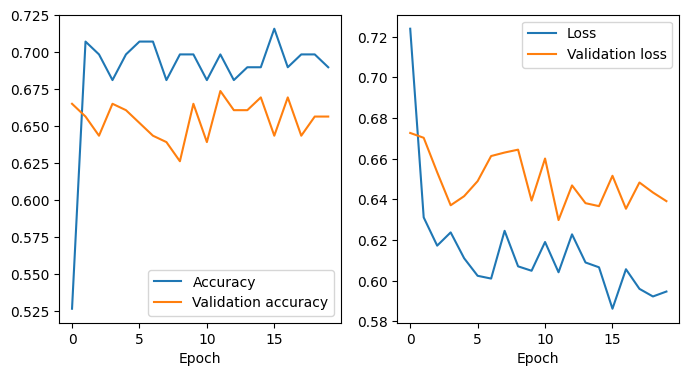

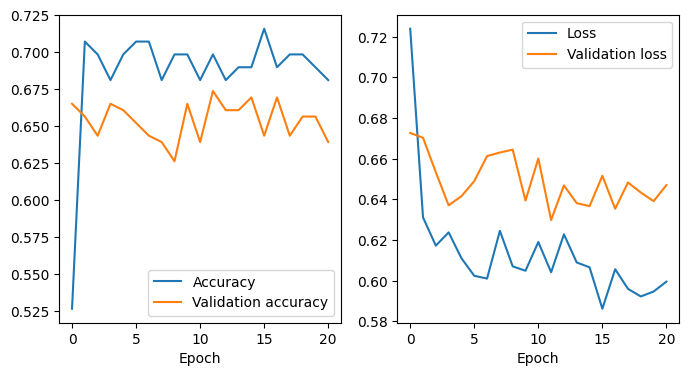

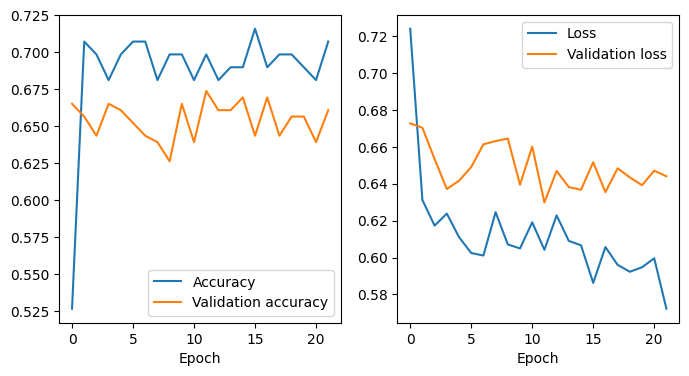

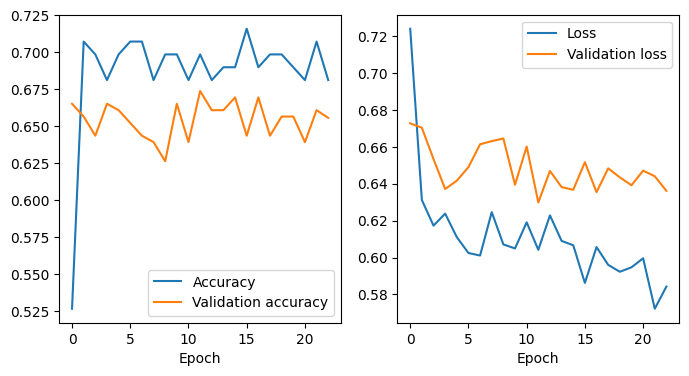

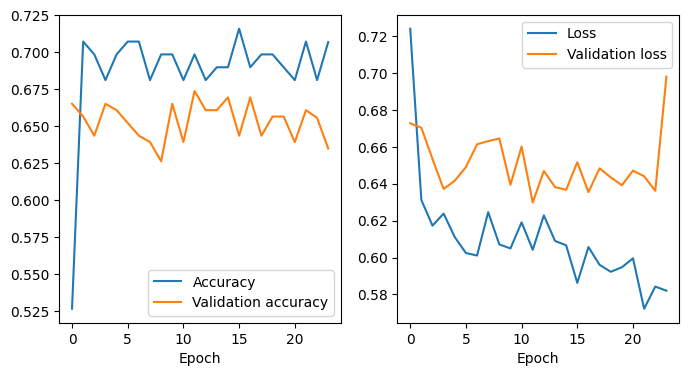

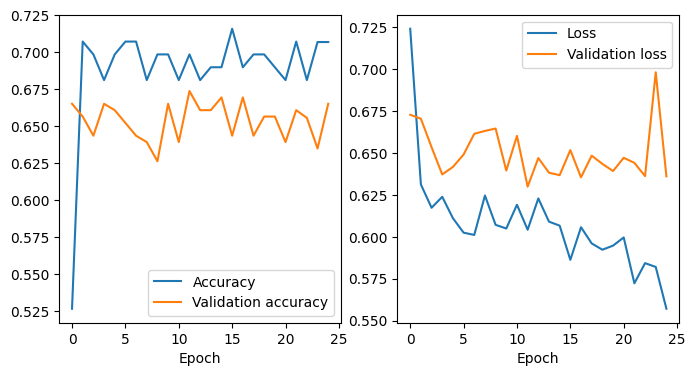

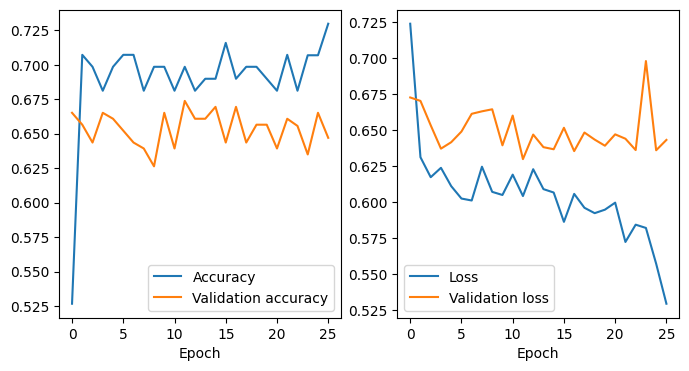

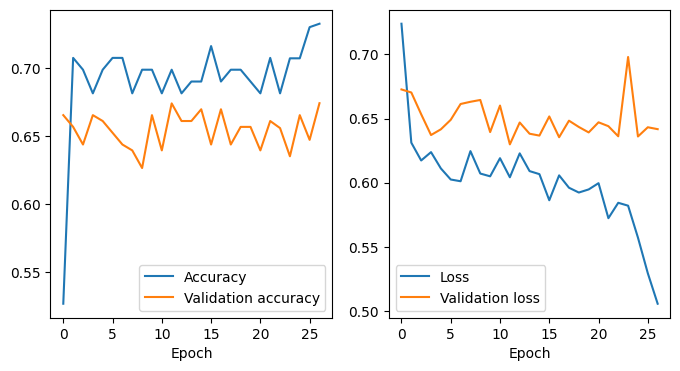

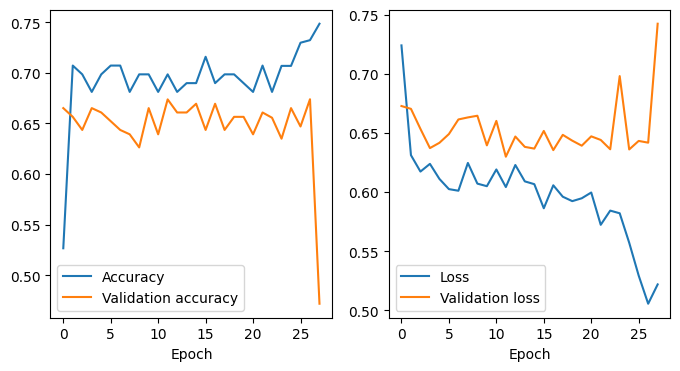

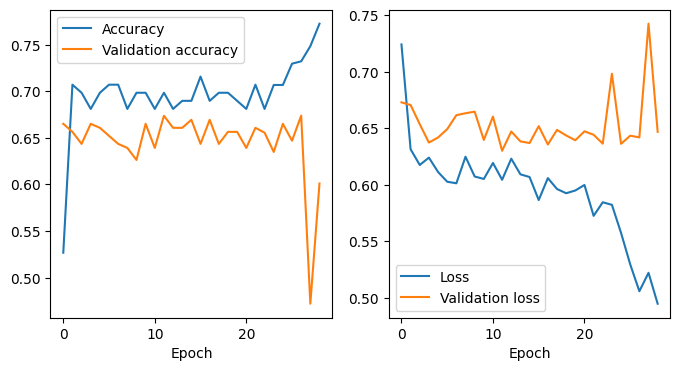

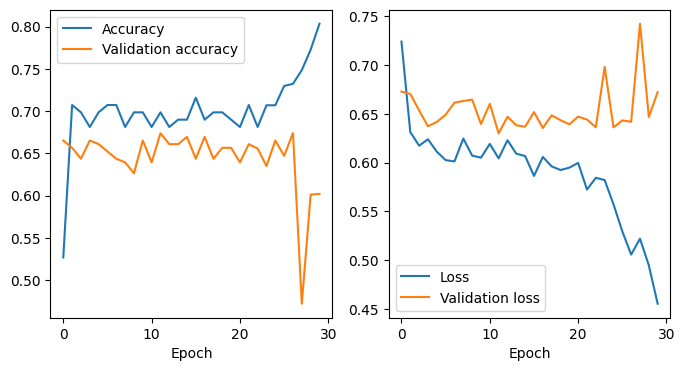

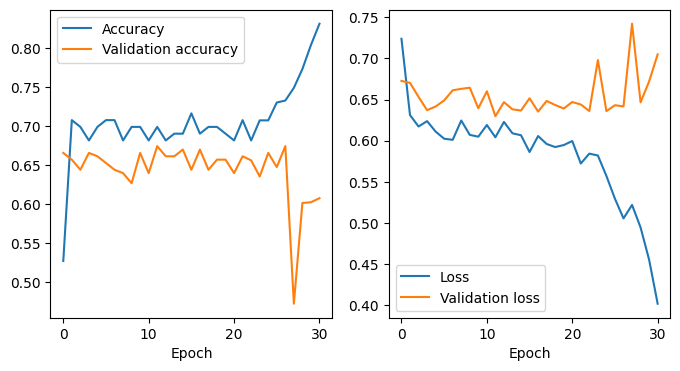

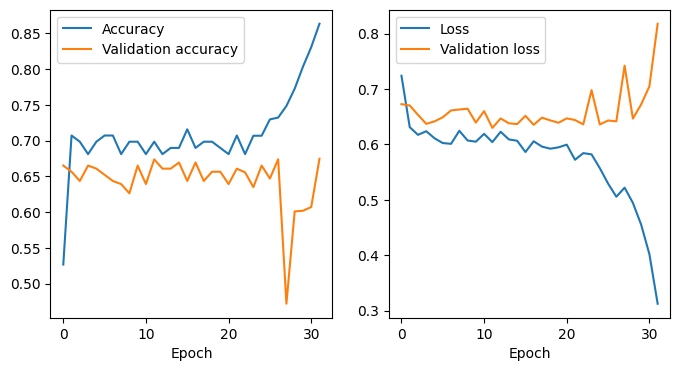

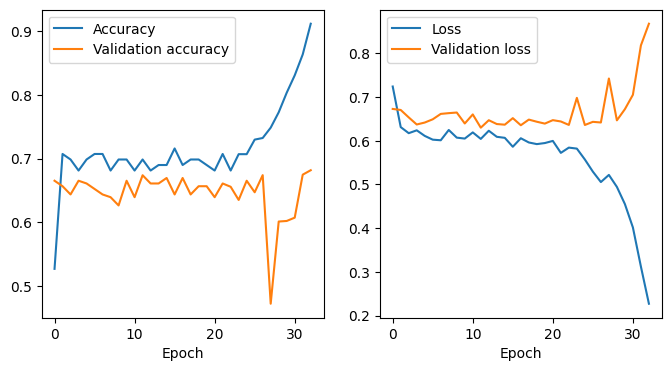

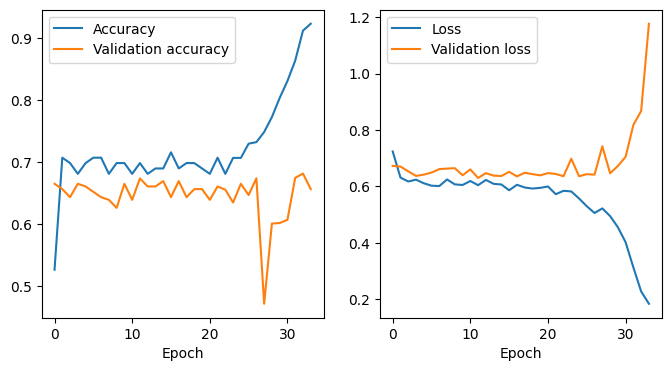

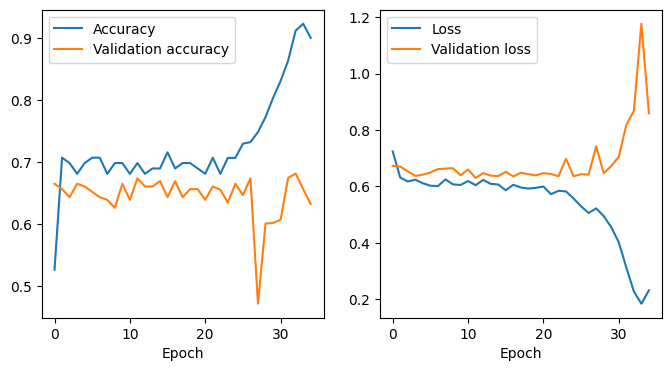

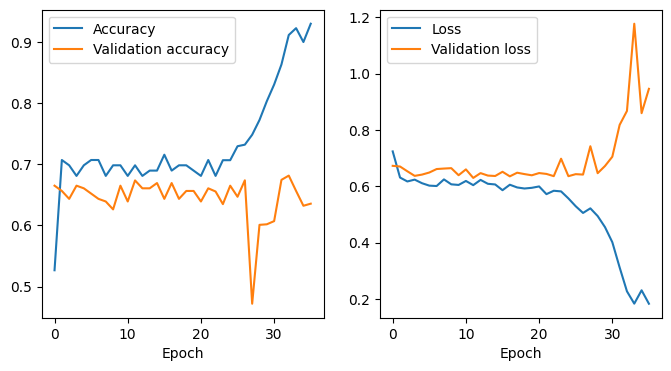

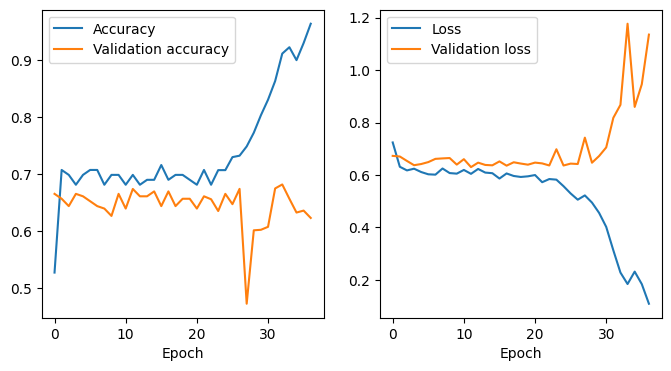

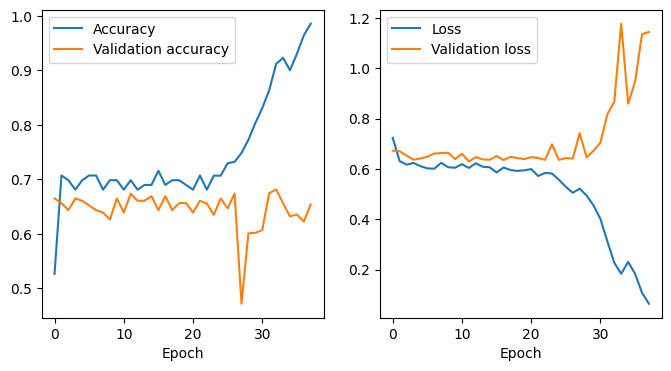

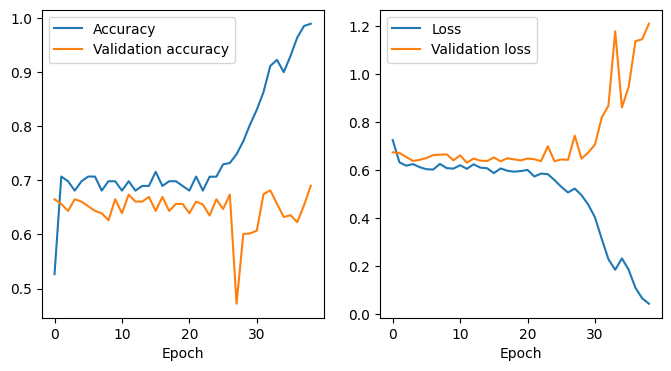

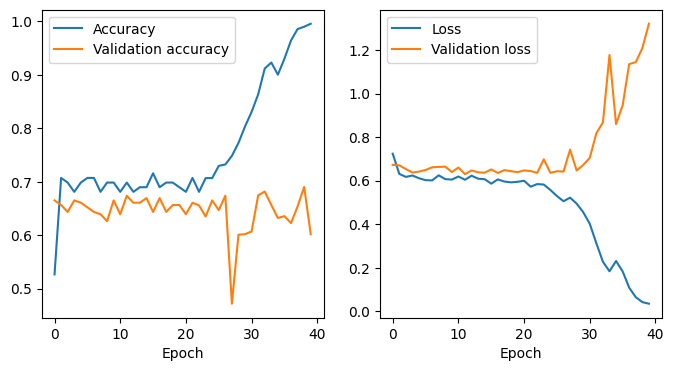

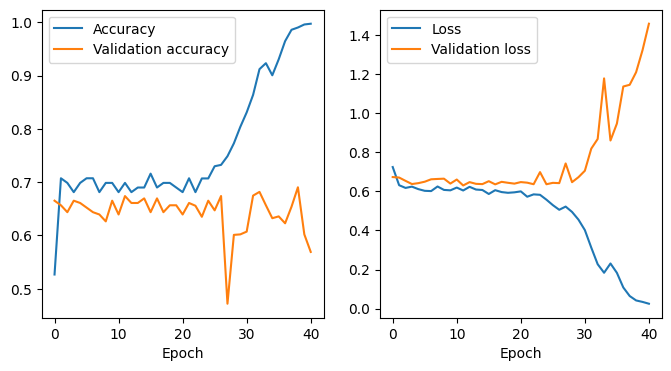

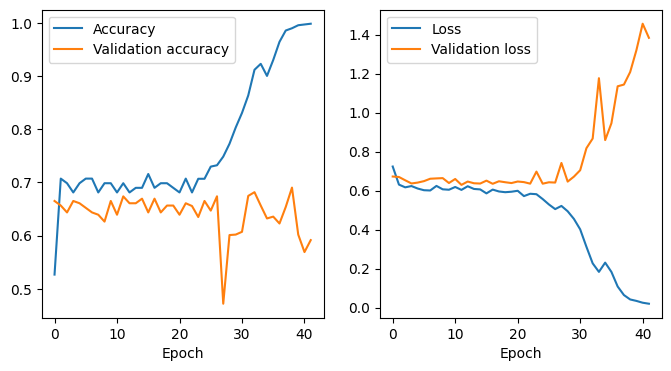

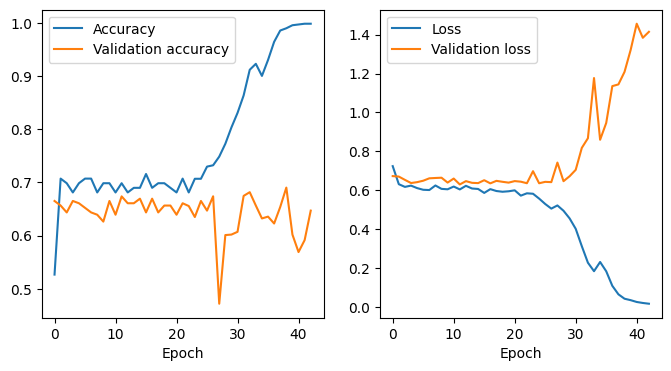

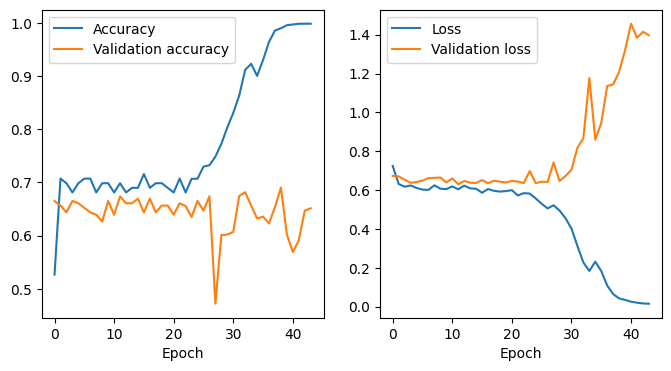

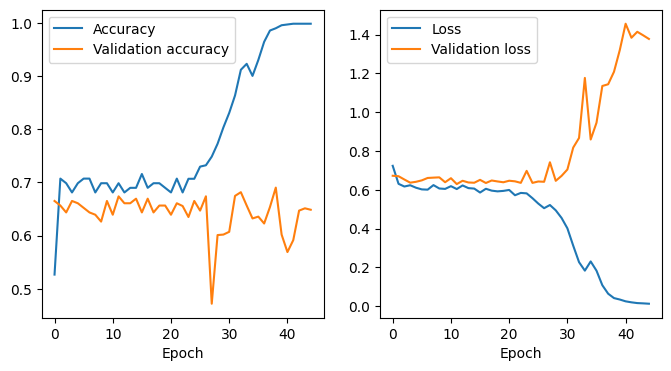

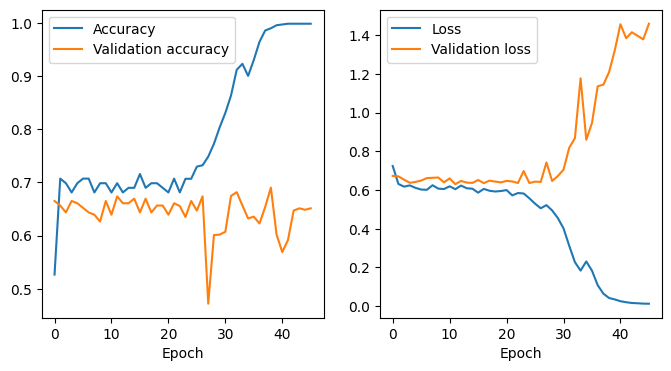

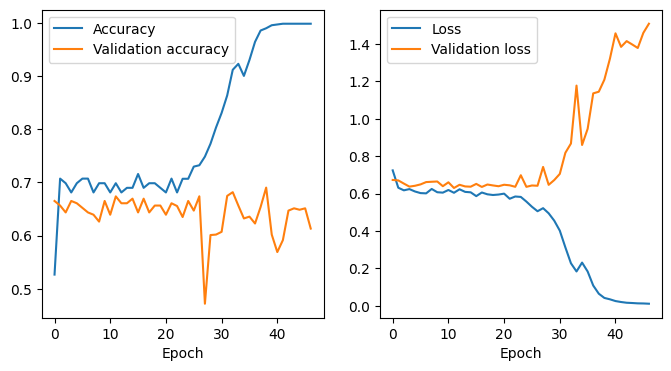

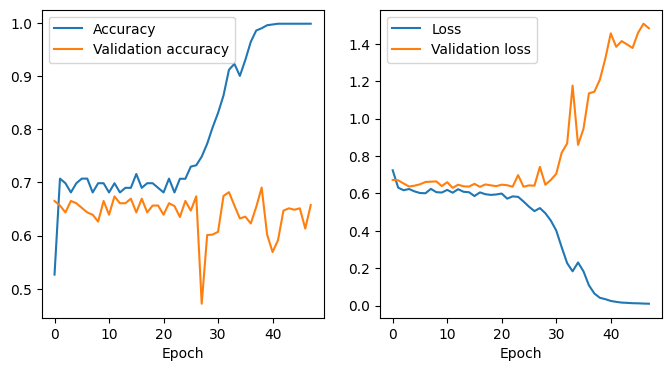

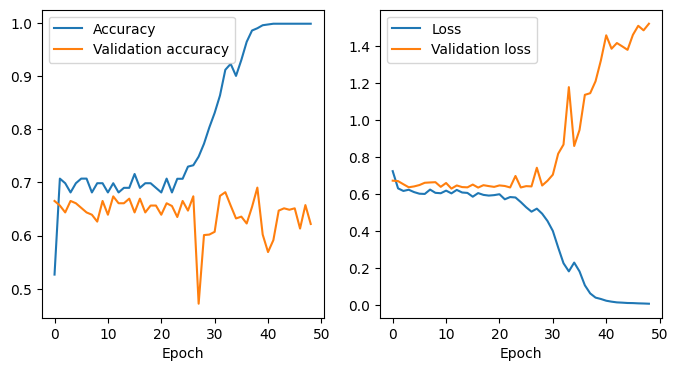

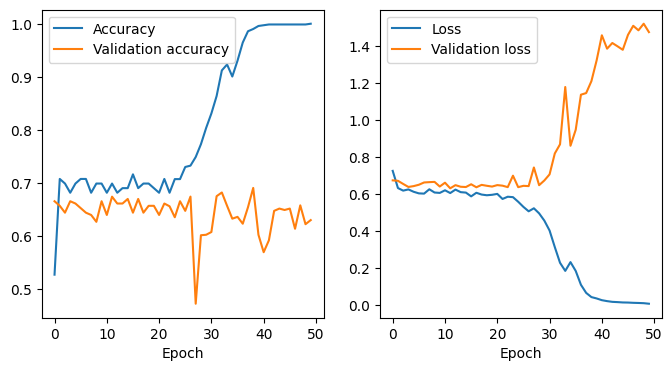

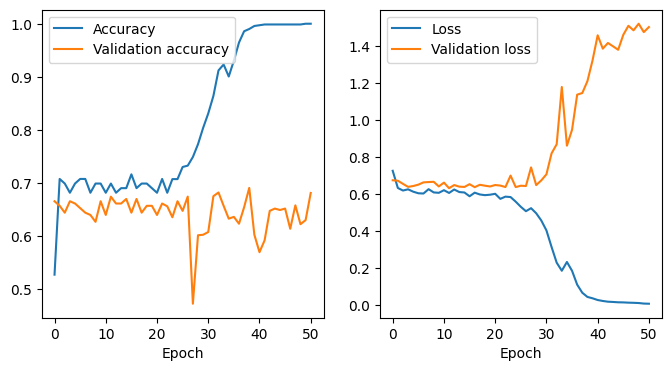

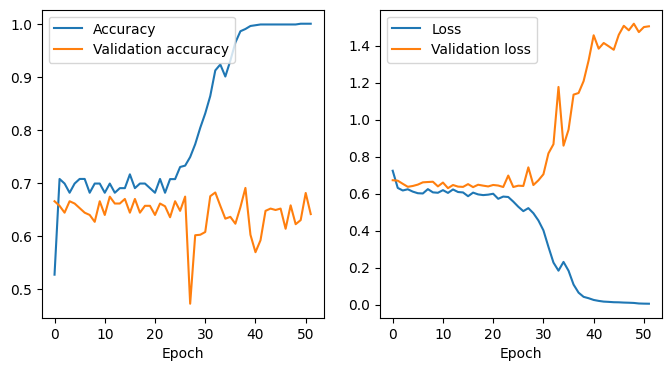

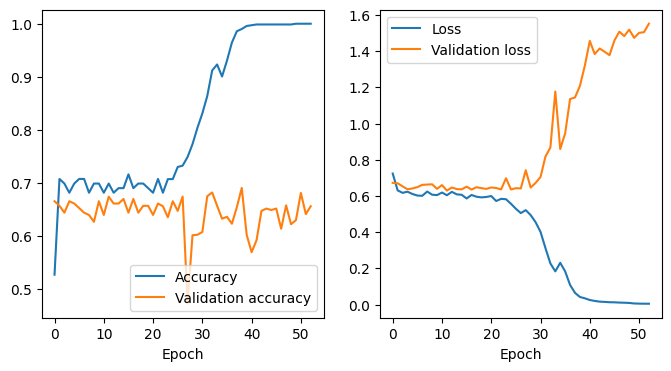

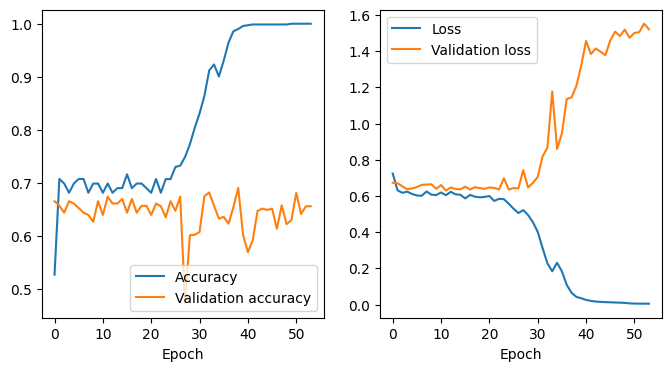

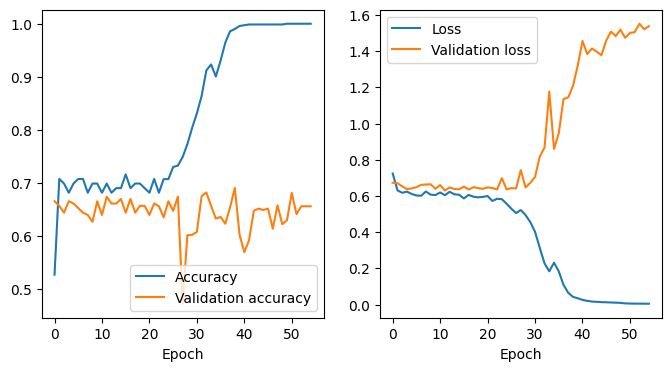

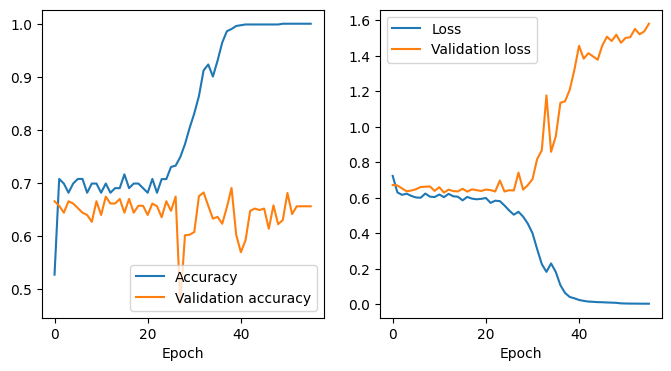

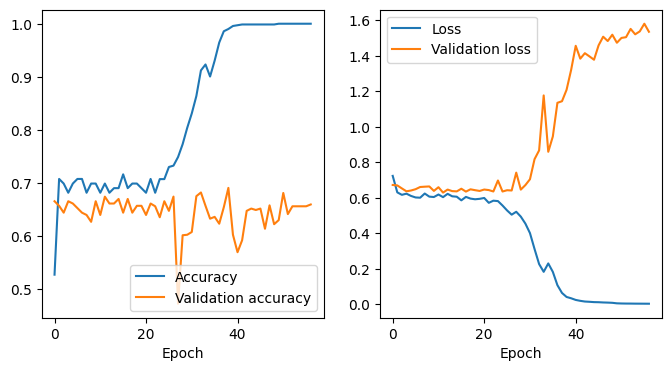

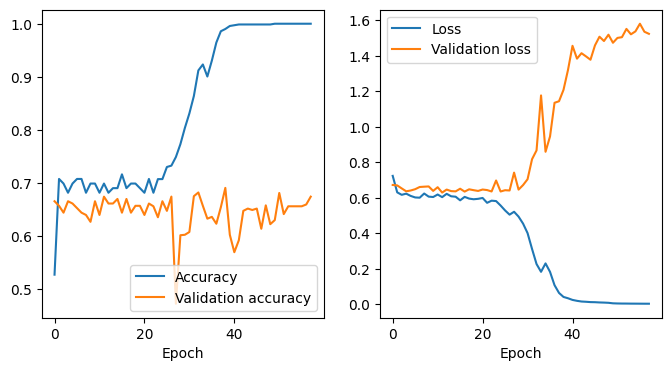

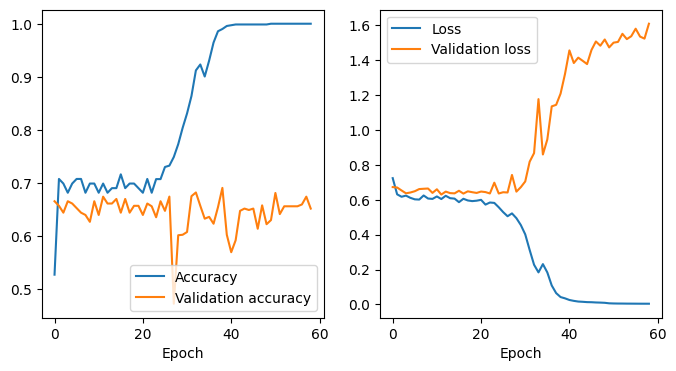

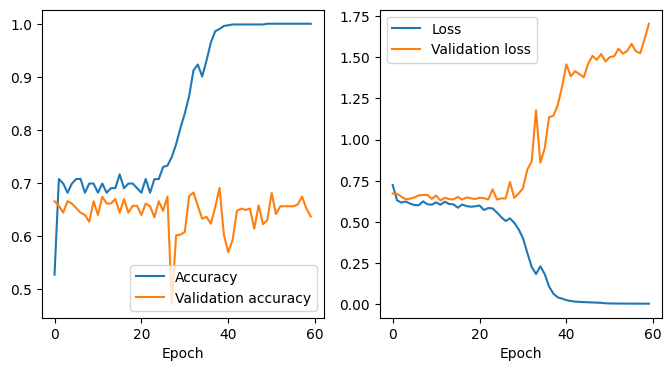

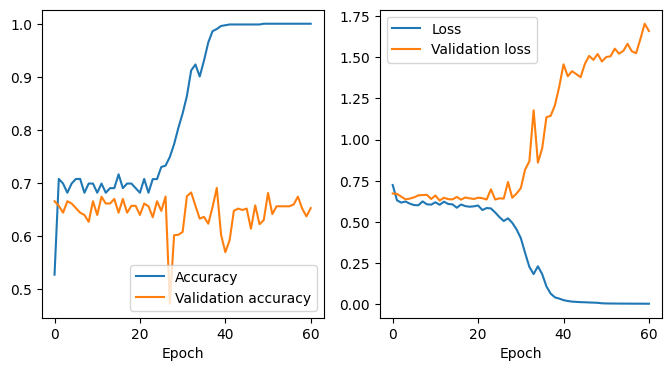

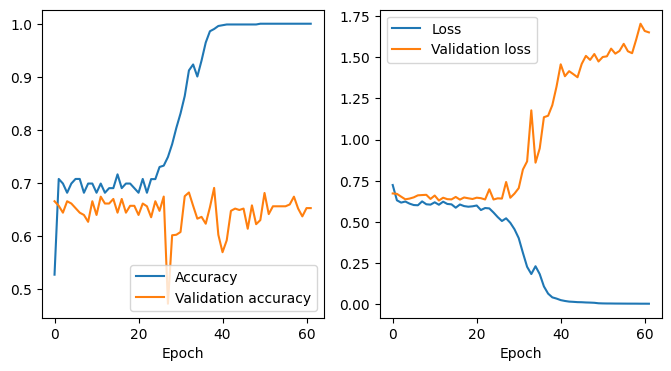

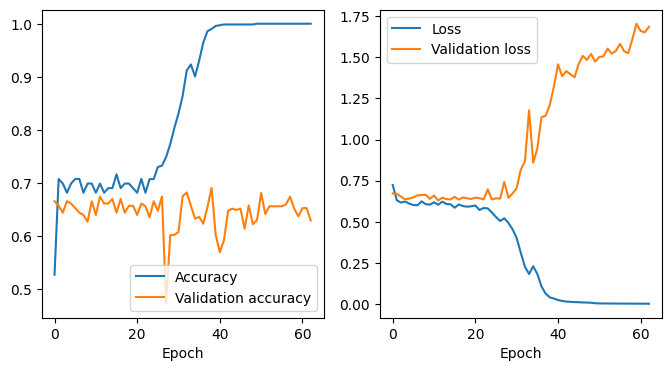

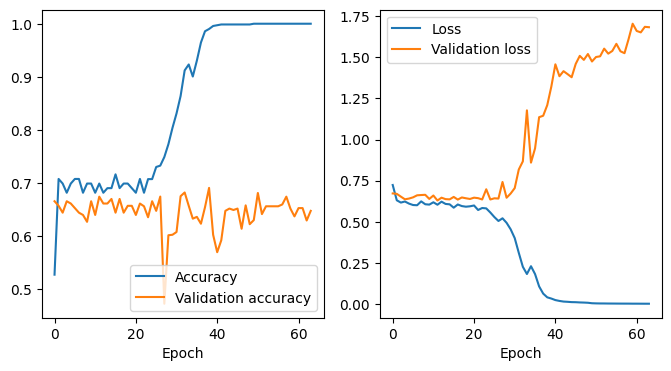

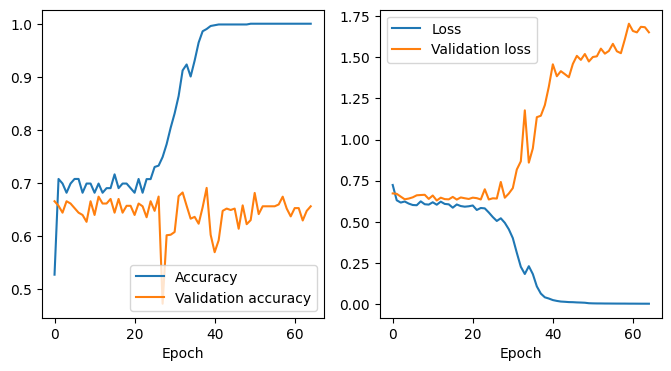

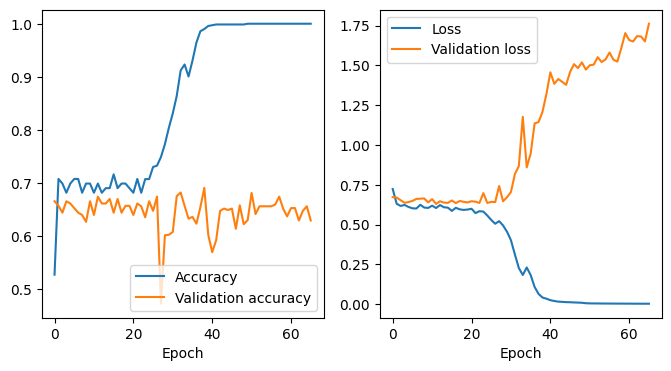

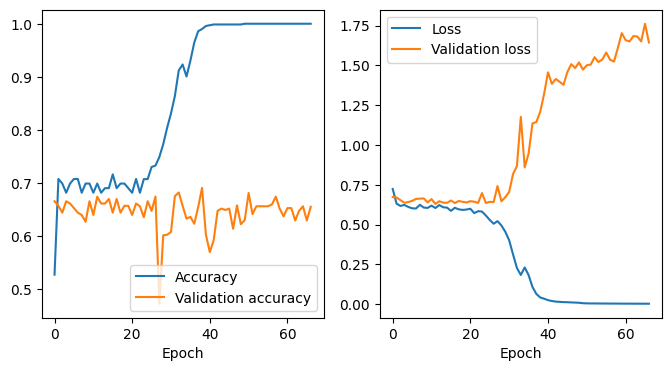

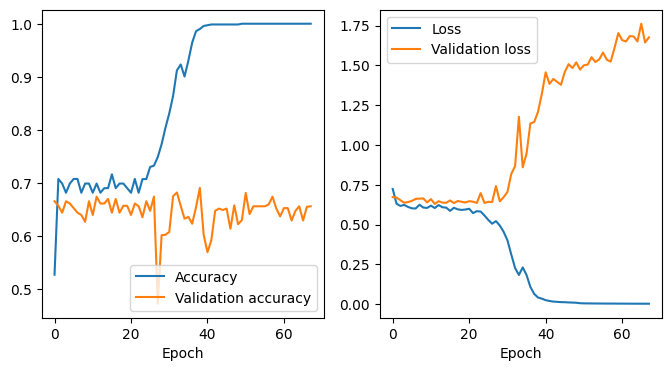

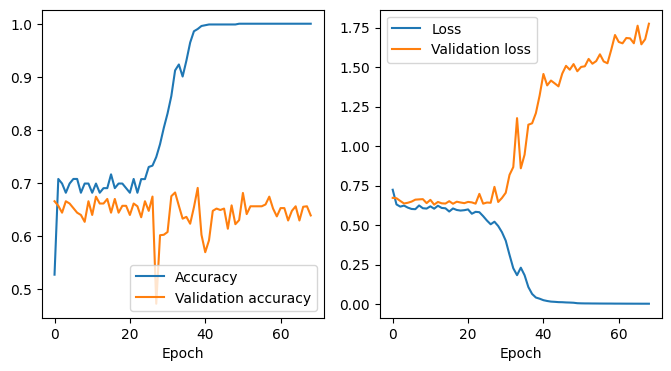

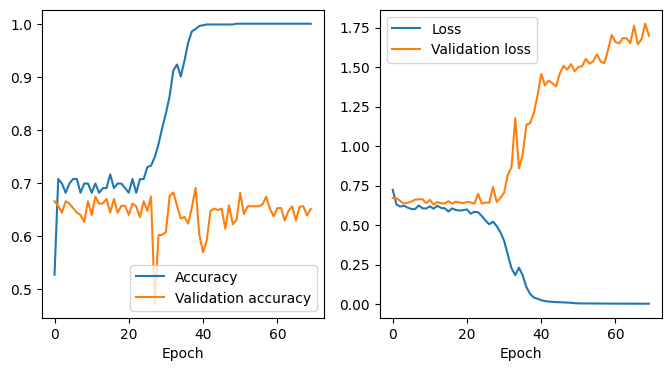

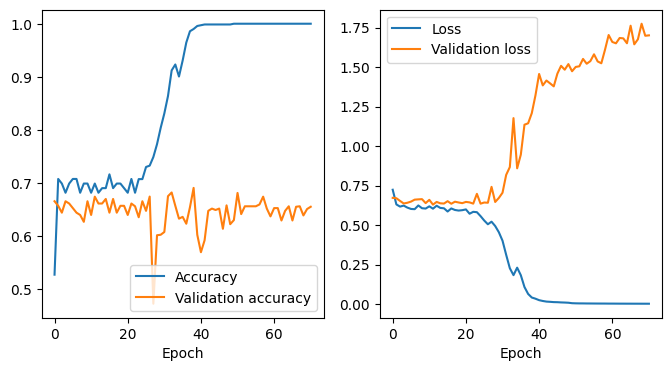

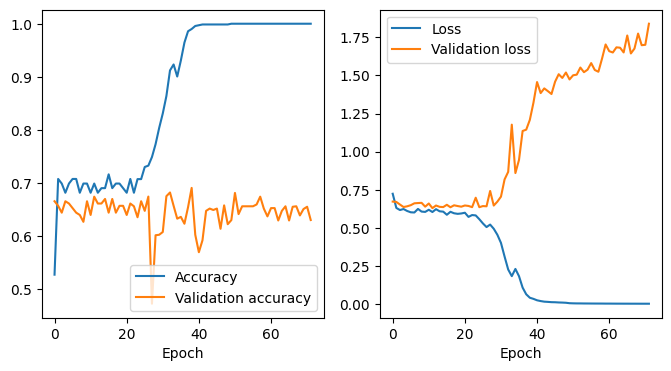

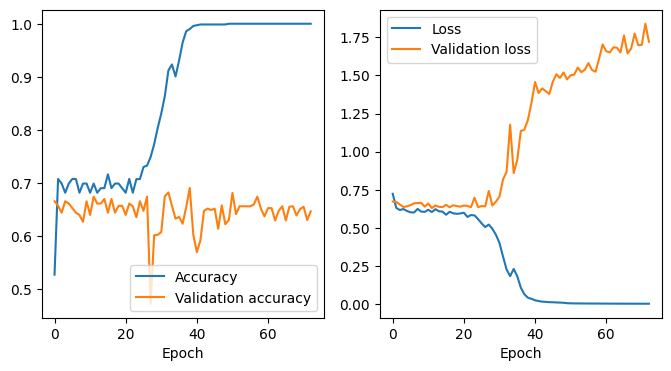

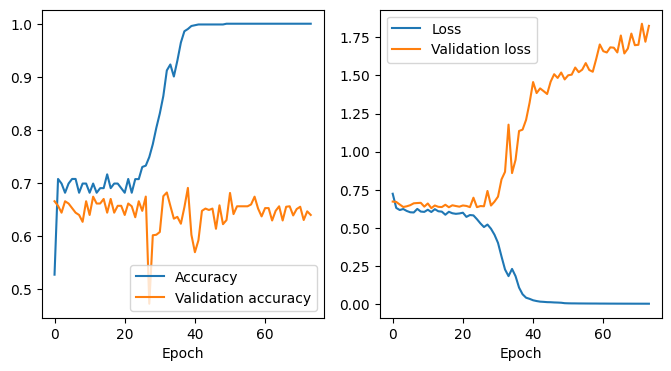

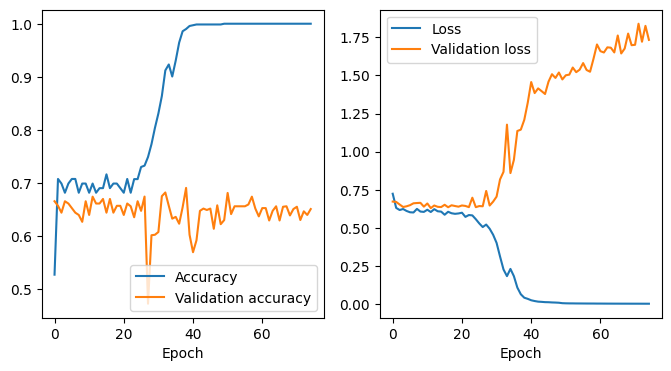

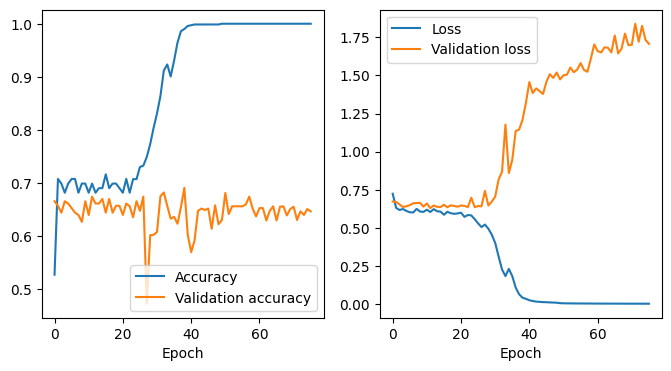

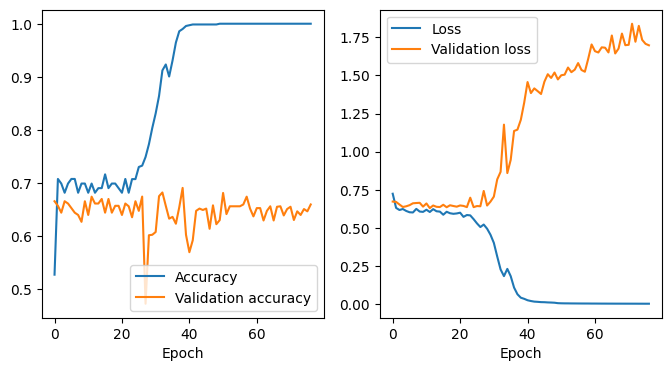

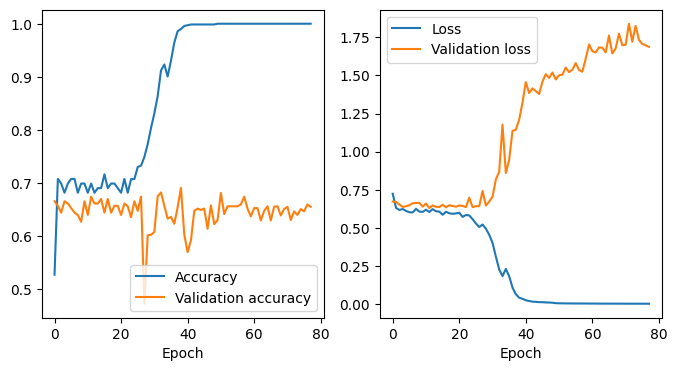

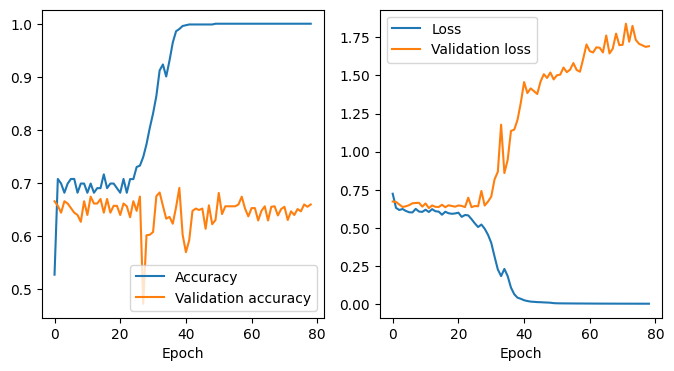

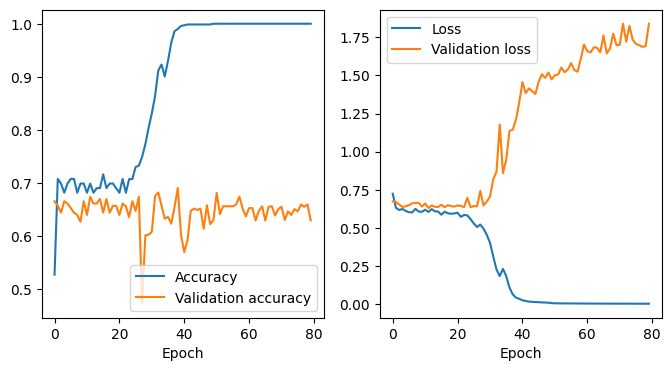

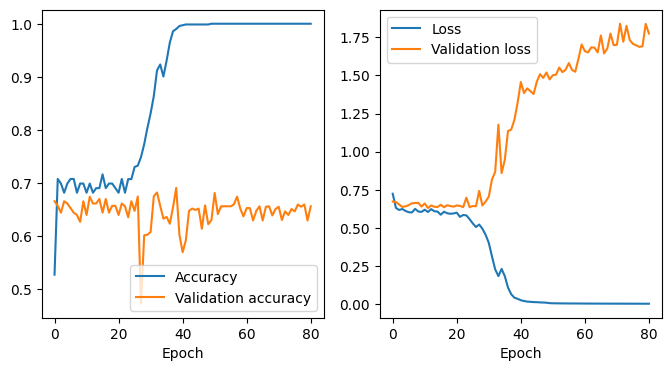

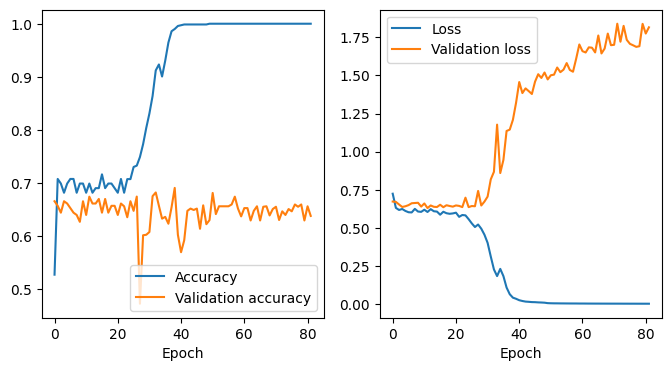

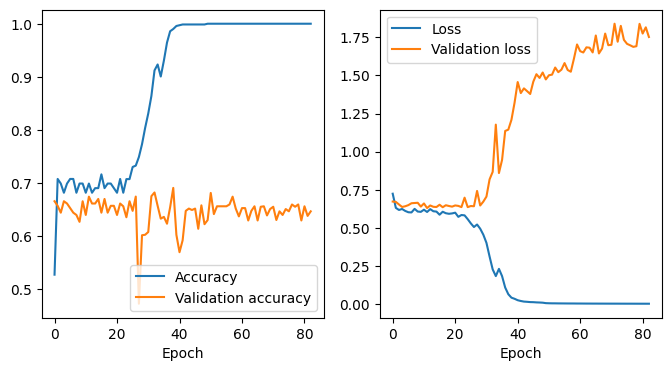

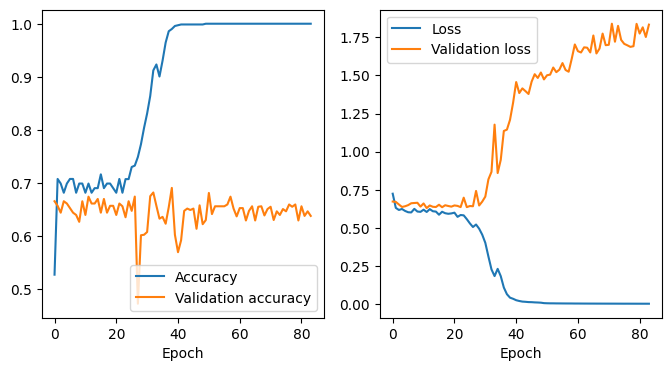

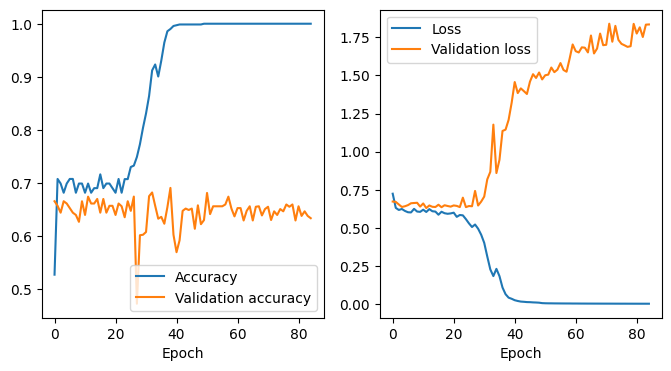

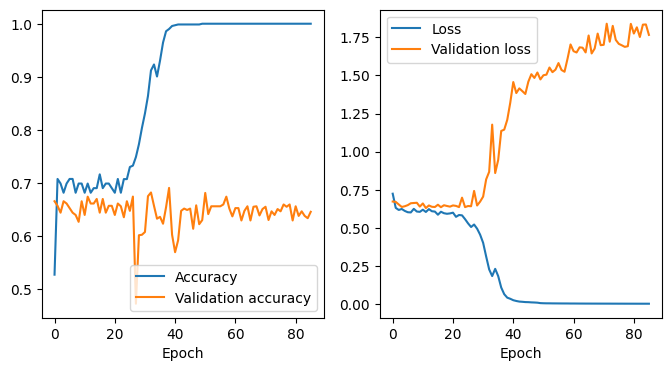

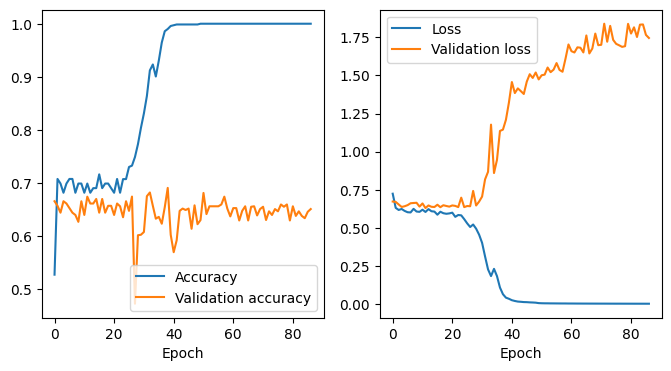

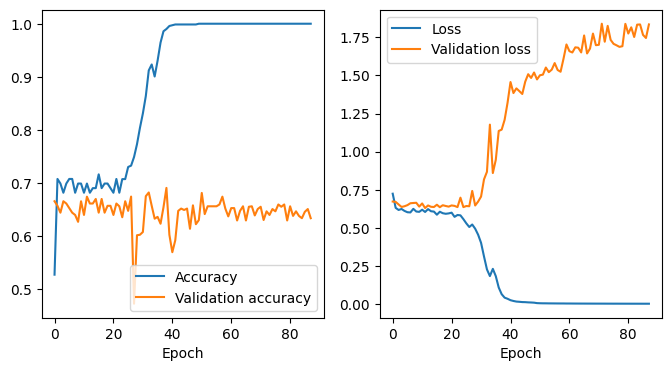

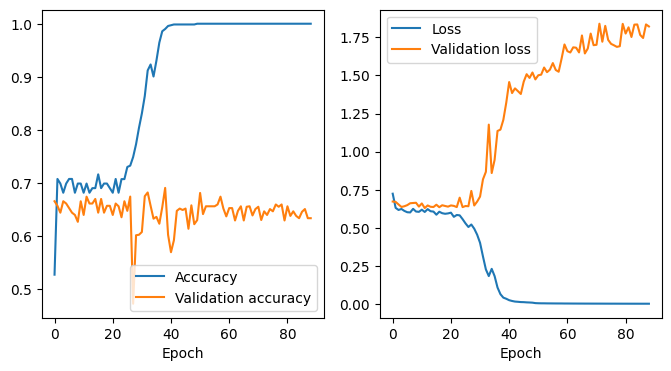

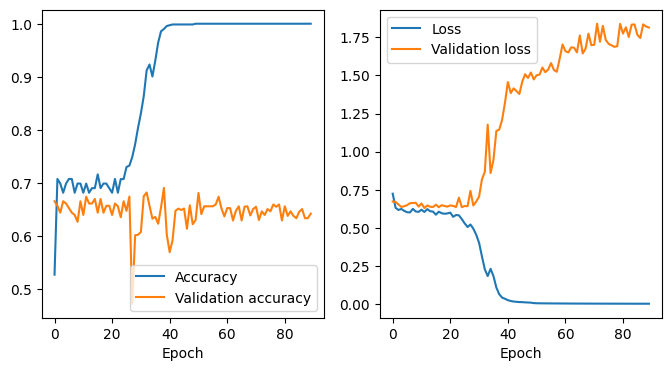

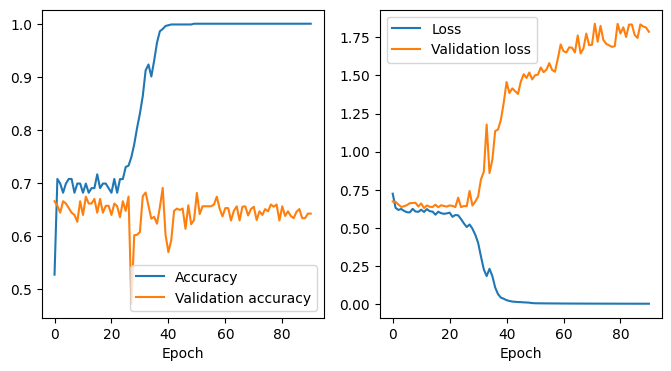

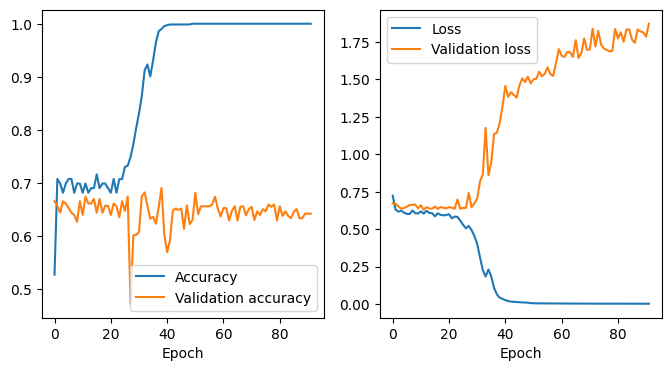

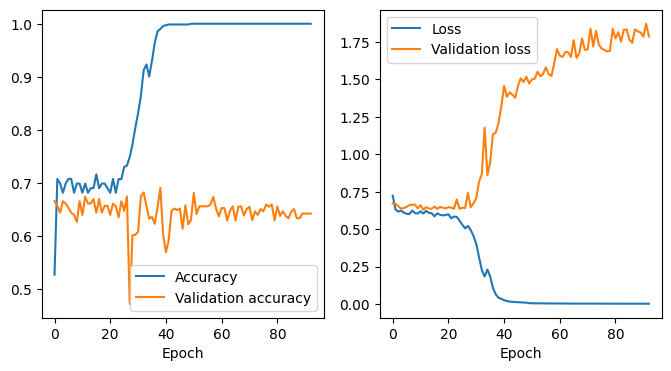

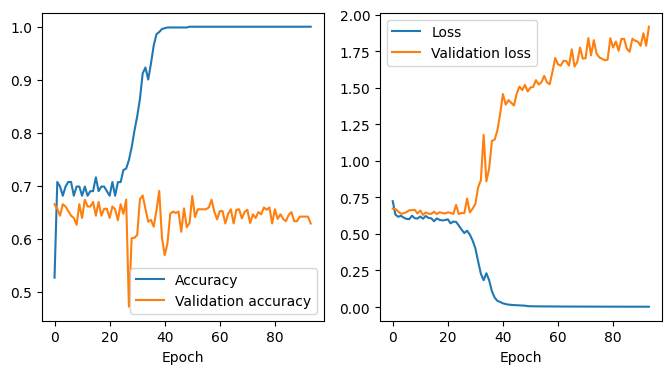

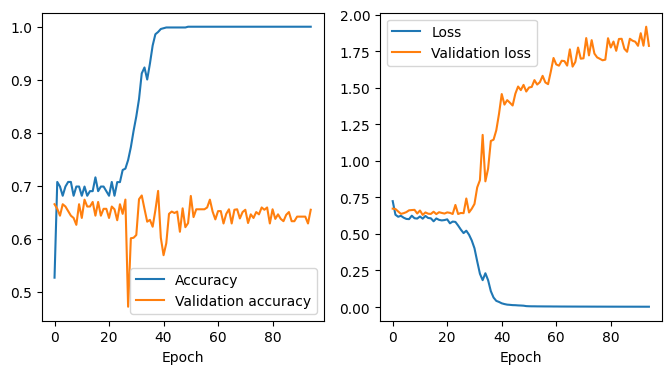

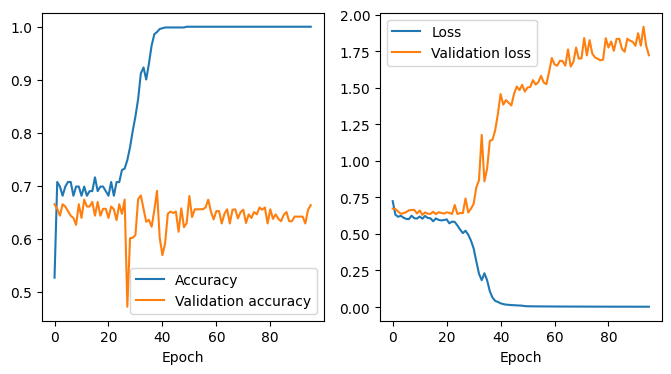

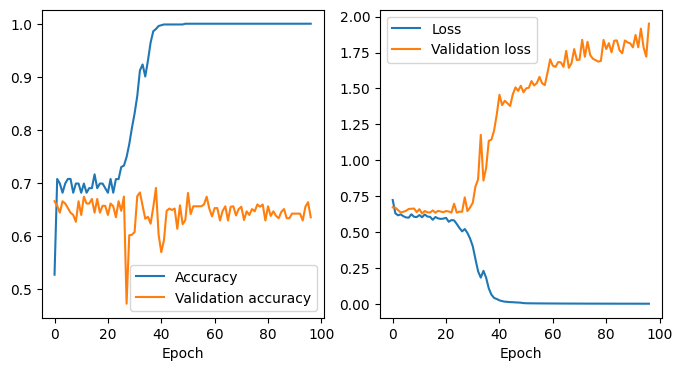

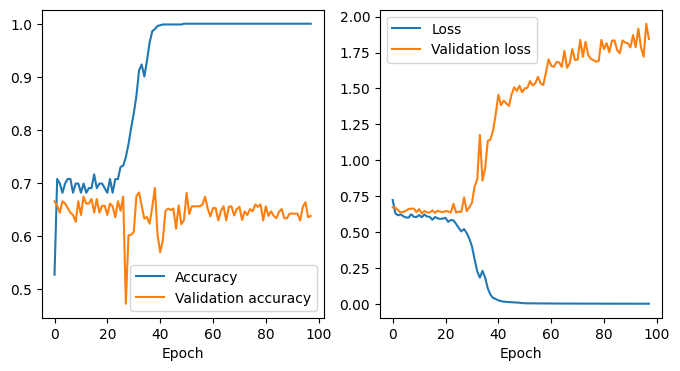

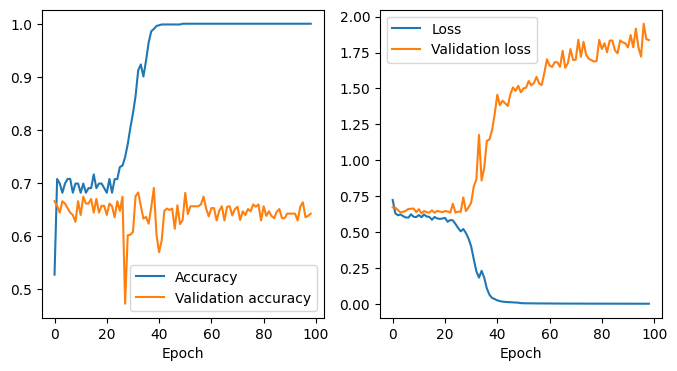

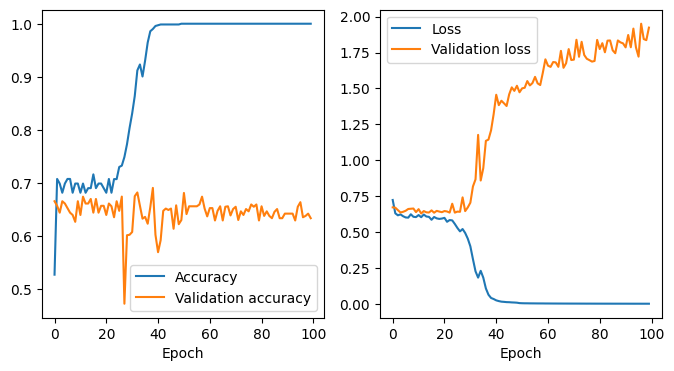

In [36]:
epoch_acc_l = []
epoch_loss_l = []
epoch_val_acc_l = []
epoch_val_loss_l = []



for epoch in range(epochs):
    epoch_loss = 0
    epoch_accuracy = 0

    for data, label in tqdm(train_loader):
        data = data.to(device)
        label = label.to(device)
        # label = label.unsqueeze(dim=1)


        output = model(data)
        output = output.squeeze()
        # print(output.shape)
        # print(output.dtype)

        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        output = (output>0.5).type(torch.float32)

        # acc = (output.argmax(dim=1) == label).float().mean()
        acc = (output == label).float().mean()
        epoch_accuracy += acc / len(train_loader)
        epoch_loss += loss / len(train_loader)

    with torch.no_grad():
        epoch_val_accuracy = 0
        epoch_val_loss = 0
        for data, label in test_loader:
            data = data.to(device)
            label = label.to(device)
            # label = label.unsqueeze(dim=1)

            val_output = model(data)
            val_output = val_output.squeeze()

            print(val_output)


            val_loss = criterion(val_output, label)
            val_output = (val_output > 0.5).type(torch.float32)

            acc = (val_output == label).float().mean()
            # acc = (val_output.argmax(dim=1) == label).float().mean()
            epoch_val_accuracy += acc / len(test_loader)
            epoch_val_loss += val_loss / len(test_loader)

    epoch_acc_l += [float(epoch_accuracy)]
    epoch_loss_l += [float(epoch_loss)]
    epoch_val_loss_l += [float(epoch_val_loss)]
    epoch_val_acc_l += [float(epoch_val_accuracy)]

    training_stats = pd.DataFrame({"Accuracy":epoch_acc_l, "Loss":epoch_loss_l, "Val Accuracy":epoch_val_acc_l, "Val Loss":epoch_val_loss_l})

    makeAccGraph(training_stats)
    print(
        f"Epoch : {epoch+1} - loss : {epoch_loss:.4f} - acc: {epoch_accuracy:.4f} - val_loss : {epoch_val_loss:.4f} - val_acc: {epoch_val_accuracy:.4f}\n"
    )
